In [1]:
import re
from pathlib import Path

import editdistance
import h5py
import lightgbm as lgb
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
from statsmodels.nonparametric.smoothers_lowess import lowess
from tqdm import tqdm

sns.set_theme(font_scale=1.5, palette='Set2')
sns.set_style('whitegrid')

DATA_DIR = Path("../data")
STRAINS_RETRO = [
    'HIV-1:CH058', 'HIV-2:GH-1', 'HIV-2:ROD', 'HIV-1:REJO',
    'Human_T-Lymphoma_Virus:Type_3', 'Human_T-Lymphoma_Virus:Type_2',
    'Human_T-Lymphoma_Virus:Type_1',
]


### Data

**NOTE**: We use Sei track predictions for transcription factors expected to primarily regulate the HIV-1 LTR core promoter: ATF, SP, RELA (NF-κB), ETS, and USF.

In [2]:
dataset = (
    pl.read_csv(DATA_DIR / "OL53.csv")
    .filter(~pl.col("sequence").is_null())
    .unique(subset=["sequence"], keep="first")
    .sort("ID", "sequence")
)

dataset = dataset.with_columns(pl.arange(dataset.height).alias("index"))

rows = []
with open(DATA_DIR / 'sei_model/target.names', 'r') as f:
    for line in f:
        parts = [p.strip() for p in line.strip().split('|')]
        if len(parts) == 3:
            cell_type, target, id_field = parts
        elif len(parts) == 4:  # e.g., line 19920 is "A549 | CTCF | ENCODE | 1"
            cell_type = parts[0]
            target = parts[1]
            id_field = 'ENCODE_' + parts[3]
        else:
            print(f"Skipping malformed line: {line}")
            continue
        rows.append([cell_type, target, id_field, line.strip()])
sei_tracks = pl.DataFrame(rows, schema=['cell_type', 'target', 'source', 'ID'], orient="row")

TFs = ['ATF', 'SP', 'RELA', 'ETS', 'USF']
pattern = r'^(?:' + '|'.join(re.escape(tf) for tf in TFs) + r')\d{0,2}$'
tf_tracks = sei_tracks.filter(pl.col("target").str.contains(pattern))
print(f"Sei tracks: {', '.join(tf_tracks["target"].unique())}")

tf_tracks.write_csv(DATA_DIR / "bst_model_tf_tracks.csv")


Sei tracks: USF2, ATF1, ATF2, RELA, ATF5, SP4, ATF3, ETS2, SP3, ETS1, SP1, SP2, ATF4, SP7, USF1


**Sei Predictions**

Predictions are obtained in [`04_obtain_sei_predictions.py`](../scripts/04_obtain_sei_predictions.py) script.

In [3]:
with h5py.File(DATA_DIR / 'OL53_sei_predictions.h5', 'r') as h5f:
    tile_ids = h5f['ID'].asstr()[:]
    all_cols = h5f['track_names'].asstr()[:]
    target_cols = tf_tracks["ID"].to_list()
    col_map = {name: i for i, name in enumerate(all_cols)}
    indices = [col_map[name] for name in target_cols]
    track_predictions = pl.from_numpy(
        h5f['track_predictions'][:][:, indices], 
        schema=target_cols
    ).with_columns(ID=tile_ids).select("ID", pl.exclude("ID"))

assert all(dataset["ID"].to_numpy() == tile_ids)


Define the target experiment (Jurkat + TNF or Jurkat + CD3+PMA).

**NOTE**: We only select tiles for which the variance between replicates is small enough.

In [4]:
# # Jurkat + TNF (log2 ratio TNF / control)
target_column = 'lfc_mean_TNFEffect'
target_column_var = 'lfc_mean_variance_Berkay_Jurkat_TNF'
dataset = dataset.with_columns((pl.col("lfc_mean_Berkay_Jurkat_TNF") - pl.col("lfc_mean_Berkay_Jurkat_Ctrl")).alias(target_column))

# # Jurkat + CD3+PMA
# target_column = 'lfc_mean_StimEffect'
# target_column_var = 'lfc_mean_variance_StimEffect'

target_df = dataset.filter(
    (~pl.col(target_column).is_null()) &
    (pl.col(target_column).abs() >= 10 * pl.col(target_column_var)) &  # NOTE: filter out tiles with large variance across replicates
    (pl.col("strain").is_in(STRAINS_RETRO))
)

print(f"Final dataset: {target_df.height} tiles.")


Final dataset: 11088 tiles.


### Similarity-Clustered train / val / test split

In [5]:
tile = 'HIV-1:REJO:6'
tile_df = target_df.filter(pl.col("ID_OL49").str.starts_with(tile))


1. Compute condensed pairwise distance matrix

In [6]:
_COMPLEMENT = str.maketrans("ACGTacgt", "TGCAtgca")

def reverse_complement(seq: str) -> str:
    return seq.translate(_COMPLEMENT)[::-1]

def strand_aware_edit(a: str, rc_a: str, b: str) -> int:
    """min(edit(a, b), edit(rc(a), b)) — accepts precomputed rc_a."""
    return min(editdistance.eval(a, b), editdistance.eval(rc_a, b))


sequences = tile_df["sequence"].to_list()
rc_sequences = [reverse_complement(s) for s in sequences]
n = len(sequences)

condensed = np.empty(n * (n - 1) // 2, dtype=np.int32)
idx = 0
for i in tqdm(range(n), desc="Pairwise edit distances"):
    for j in range(i + 1, n):
        condensed[idx] = strand_aware_edit(sequences[i], rc_sequences[i], sequences[j])
        idx += 1


Pairwise edit distances:   0%|          | 3/1792 [00:00<01:21, 22.06it/s]

Pairwise edit distances: 100%|██████████| 1792/1792 [00:40<00:00, 44.26it/s] 


2. Inspect distance distribution and choose the appropraite threshold. This threshold guarantees that for any pair (validation / test sequence, train sequence) the edit distance is equal or greater to the treshold. 

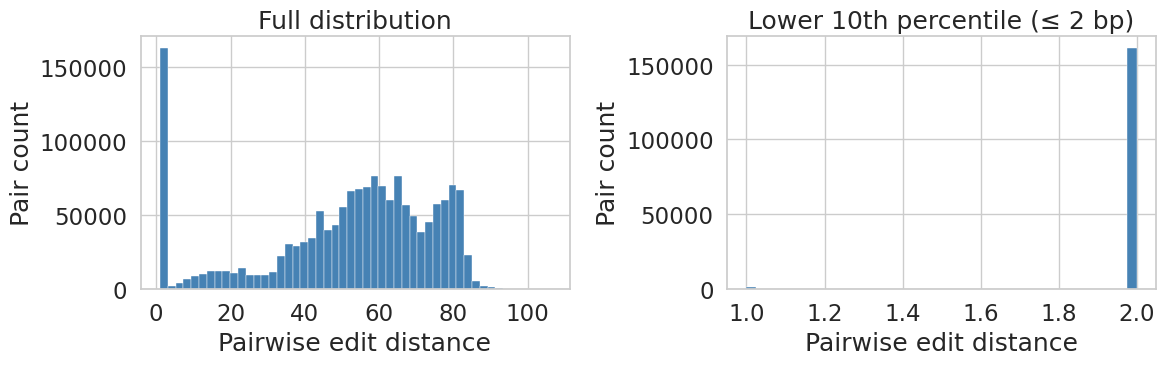

    1th percentile: 2.0
    5th percentile: 2.0
   10th percentile: 2.0
   25th percentile: 40.0
   50th percentile: 56.0
   75th percentile: 69.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(condensed, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Pairwise edit distance")
axes[0].set_ylabel("Pair count")
axes[0].set_title("Full distribution")

p10 = int(np.percentile(condensed, 10))
axes[1].hist(condensed[condensed <= p10], bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Pairwise edit distance")
axes[1].set_ylabel("Pair count")
axes[1].set_title(f"Lower 10th percentile (≤ {p10} bp)")

plt.tight_layout()
plt.show()

for p in [1, 5, 10, 25, 50, 75]:
    print(f"  {p:>3}th percentile: {np.percentile(condensed, p):.1f}")


3. Cluster by connected components (guarantees the threshold condition).

In [8]:
THRESHOLD = 10

def cluster_by_connected_components(condensed: np.ndarray, n: int, threshold: int) -> np.ndarray:
    """
    Assigns cluster labels via connected components of the similarity graph.
    Any two sequences with edit distance <= threshold are connected by an edge.
    Guarantees: all cross-cluster pairs have distance > threshold.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n))
    idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            if condensed[idx] <= threshold:
                G.add_edge(i, j)
            idx += 1

    labels = np.empty(n, dtype=int)
    for component_id, component in enumerate(nx.connected_components(G), start=1):
        for node in component:
            labels[node] = component_id

    return labels


cluster_labels = cluster_by_connected_components(condensed, n, threshold=THRESHOLD)

cluster_sizes = np.bincount(cluster_labels)[1:]
print(f"Threshold         : {THRESHOLD}")
print(f"N components      : {cluster_labels.max()}")
print(f"Cluster sizes     : min={cluster_sizes.min()}, "
      f"median={np.median(cluster_sizes):.0f}, max={cluster_sizes.max()}")
print(f"Singleton clusters: {(cluster_sizes == 1).sum()}")


Threshold         : 10
N components      : 436
Cluster sizes     : min=1, median=1, max=569
Singleton clusters: 345


4. Assign clusters to train / val / test.

In [9]:
def assign_clusters_to_splits(
    cluster_labels: np.ndarray,
    train_fraction: float = 0.70,
    valid_fraction: float = 0.15,
    random_seed: int = 42,
) -> np.ndarray:
    """
    Greedy cluster-level split assignment (first-fit-decreasing heuristic).

    Clusters are sorted largest-first (with random tie-breaking) and assigned
    to whichever split has the largest remaining deficit relative to its target
    size. This minimises split-fraction deviation while keeping every cluster
    entirely within one partition.

    Returns a per-sequence array of split labels ("train" / "val" / "test").
    """
    rng     = np.random.default_rng(random_seed)
    n_total = len(cluster_labels)

    unique_clusters, counts = np.unique(cluster_labels, return_counts=True)

    # Primary sort: descending cluster size; tie-break: random
    order           = np.lexsort((rng.random(len(counts)), -counts))
    unique_clusters = unique_clusters[order]
    counts          = counts[order]

    targets = {
        "train": round(n_total * train_fraction),
        "val": round(n_total * valid_fraction),
    }
    targets["test"] = n_total - targets["train"] - targets["val"]
    filled = {k: 0 for k in targets}
    cluster_to_split = {}

    for cid, size in zip(unique_clusters, counts):
        chosen = max(targets, key=lambda s: targets[s] - filled[s])
        cluster_to_split[cid] = chosen
        filled[chosen] += size

    print("\nActual split sizes    :", filled)
    print("Actual split fractions:", {k: f"{v/n_total:.3f}" for k, v in filled.items()})

    return np.array([cluster_to_split[c] for c in cluster_labels])


split_labels = assign_clusters_to_splits(cluster_labels)

# Add split column to tile_df
tile_df = tile_df.with_columns(
    pl.Series("split_gbdt", split_labels)
)

print(tile_df["split_gbdt"].value_counts())



Actual split sizes    : {'train': np.int64(1254), 'val': np.int64(269), 'test': np.int64(269)}
Actual split fractions: {'train': '0.700', 'val': '0.150', 'test': '0.150'}
shape: (3, 2)
┌────────────┬───────┐
│ split_gbdt ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ test       ┆ 269   │
│ train      ┆ 1254  │
│ val        ┆ 269   │
└────────────┴───────┘


### Train and evaluate GBDT on selected Sei outputs

In [10]:
param = {
    'num_leaves': 100,
    'deterministic': True,
    'max_depth': 15,
    'min_data_in_leaf': 5,
    # 'min_gain_to_split': 1e-3,  # regularization
    # 'min_child_weight': 1,  # regularization
    'learning_rate': 0.04,
    'boosting': 'gbdt',
    'objective': 'rmse',
    'num_iterations': 3000,  # alias for 'n_estimators'
    'feature_fraction': .25,
}

# # Jurkat + TNF (log2 ratio TNF / control)
model_path = DATA_DIR / f"{tile.replace(':', '_')}_Jurkat_TNF_model.txt"

# # Jurkat + CD3+PMA
# model_path = DATA_DIR / f"{tile.replace(':', '_')}_Jurkat_CD3-PMA_model.txt"

train_df = tile_df.filter(pl.col("split_gbdt") == "train")
valid_df = tile_df.filter(pl.col("split_gbdt") == "val")
test_df = tile_df.filter(pl.col("split_gbdt") == "test")

X_tr = track_predictions[train_df["index"]].drop("ID").to_numpy()
y_tr = train_df[target_column].to_numpy()

X_val = track_predictions[valid_df["index"]].drop("ID").to_numpy()
y_val = valid_df[target_column].to_numpy()

X_test = track_predictions[test_df["index"]].drop("ID").to_numpy()
y_test = test_df[target_column].to_numpy()

print(f"{y_tr.shape[0]} train, {y_val.shape[0]} validation, {y_test.shape[0]} test tiles")

# TRAINING
feature_name = tf_tracks["ID"].str.replace(' | ', '-').str.replace(':', '.')
train_data = lgb.Dataset(X_tr, label=y_tr, feature_name=feature_name.to_list())
val_data = lgb.Dataset(X_val, label=y_val, feature_name=feature_name.to_list())
bst = lgb.train(param, train_data, valid_sets=[val_data], callbacks=[lgb.early_stopping(stopping_rounds=50)])
bst.save_model(model_path)


1254 train, 269 validation, 269 test tiles
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 70890
[LightGBM] [Info] Number of data points in the train set: 1254, number of used features: 278
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 1.141427
Training until validation scores don't improve for 50 rounds


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[68]	valid_0's l2: 0.0338214


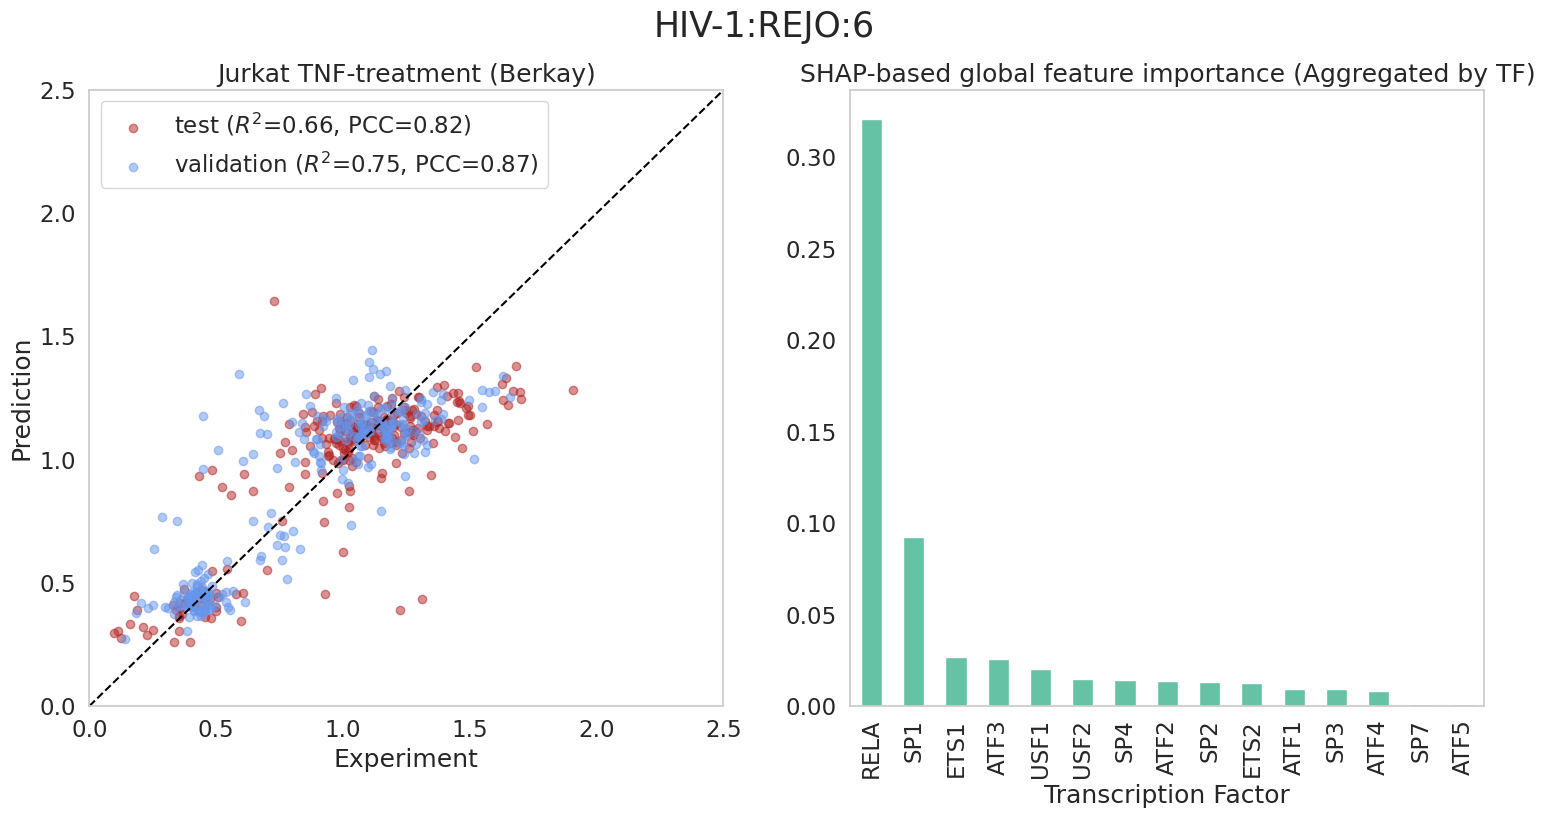

In [11]:
bst_trained = lgb.Booster(model_file=model_path)
val_pred = bst_trained.predict(X_val, num_iteration=bst_trained.best_iteration)
test_pred = bst_trained.predict(X_test, num_iteration=bst_trained.best_iteration)
tile_df = tile_df.join(
    pl.concat([
        valid_df.select("index").with_columns(pl.Series("pred_gbdt", val_pred)),
        test_df.select("index").with_columns(pl.Series("pred_gbdt", test_pred)),
    ]),
    on="index",
    how="left",
)

test_r2 = r2_score(y_test, test_pred)
test_pcc = pearsonr(test_pred, y_test).statistic
val_r2 = r2_score(y_val, val_pred)
val_pcc = pearsonr(val_pred, y_val).statistic

fig, (ax_pred, ax_feature) = plt.subplots(figsize=(18, 8), ncols=2)
fig.suptitle(tile, fontsize=25)
ax_pred.scatter(y_test, test_pred, alpha=.5, color='firebrick', label=f'test ($R^2$={test_r2:.2}, PCC={test_pcc:.2})')
ax_pred.scatter(y_val, val_pred, alpha=.5, color='cornflowerblue', label=f'validation ($R^2$={val_r2:.2}, PCC={val_pcc:.2})')
ax_pred.plot([0, 5], [0, 5], ls='--', color='black')
ax_pred.set_xlabel('Experiment')
ax_pred.set_ylabel('Prediction')

ax_pred.set_title('Jurkat TNF-treatment (Berkay)')
ax_pred.set_xlim([0, 2.5])
ax_pred.set_ylim([0, 2.5])

# ax_pred.set_title(f'Jurkat Stimulation (CD3+PMA)')
# ax_pred.set_xlim([0, 4])
# ax_pred.set_ylim([0, 4])

ax_pred.legend(loc='upper left')
ax_pred.grid(False)


contribs = bst_trained.predict(X_val, pred_contrib=True)  # contribs_df = pd.DataFrame(contribs, columns=bst.feature_name() + ['bias'])
shap_values = contribs[:, :-1]
mean_abs_shap = np.abs(shap_values).mean(axis=0)
(
    pl.DataFrame({"feature": bst_trained.feature_name(), "importance": mean_abs_shap})
    .with_columns(
        pl.col("feature")
        .str.split("|")
        .list.get(1)
        .str.strip_chars("_")
        .alias("tf")
    )
    .group_by("tf")
    .agg(pl.col("importance").sum())
    .sort("importance", descending=True)
    .head(20)
    .to_pandas()
    .set_index("tf")
    .plot(ax=ax_feature, kind='bar', color='#66c2a5', legend=False)
)
ax_feature.set_title('SHAP-based global feature importance (Aggregated by TF)')
ax_feature.set_xlabel('Transcription Factor')
ax_feature.grid(False)
plt.savefig(DATA_DIR / "figures/larm_evaluation.pdf", format="pdf", bbox_inches="tight")
# plt.close()


### Post-hoc control

Prediction error vs. distance to nearest training sequence.

Min dist to train (val):  28%|██▊       | 76/269 [00:02<00:05, 33.35it/s]

Min dist to train (test): 100%|██████████| 269/269 [00:08<00:00, 32.89it/s]


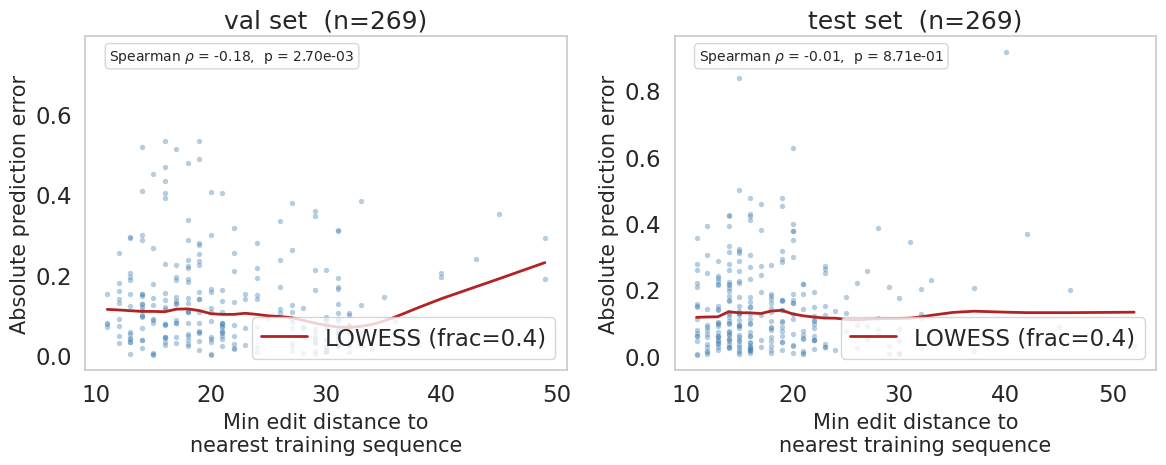

In [12]:
def plot_error_vs_min_train_distance(
    tile_df: pl.DataFrame,
    pred_col: str,
    target_col: str,
    split_col: str = "split_gbdt",
    lowess_frac: float = 0.4,
    save_path: str = "error_vs_distance.png",
) -> None:
    """
    For each val/test sequence, compute its minimum strand-aware edit distance
    to any training sequence, then scatter plot absolute prediction error
    against that distance.

    Overlays a LOWESS trend line and annotates Spearman ρ + p-value to indicate
    whether prediction error depends on similarity to the training set.
    """
    train_seqs = tile_df.filter(pl.col(split_col) == "train")["sequence"].to_list()
    rc_train   = [reverse_complement(s) for s in train_seqs]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, split in zip(axes, ["val", "test"]):
        subset     = tile_df.filter(pl.col(split_col) == split)
        query_seqs = subset["sequence"].to_list()
        rc_query   = [reverse_complement(s) for s in query_seqs]

        min_dists = np.array([
            min(strand_aware_edit(q, rcq, t) for t, _ in zip(train_seqs, rc_train))
            for q, rcq in tqdm(zip(query_seqs, rc_query),
                               total=len(query_seqs),
                               desc=f"Min dist to train ({split})")
        ])

        errors = np.abs(subset[pred_col].to_numpy() - subset[target_col].to_numpy())

        # Scatter
        ax.scatter(min_dists, errors, alpha=0.4, s=15,
                   color="steelblue", linewidths=0, zorder=2)

        # LOWESS trend line
        smoothed = lowess(errors, min_dists, frac=lowess_frac, return_sorted=True)
        ax.plot(smoothed[:, 0], smoothed[:, 1],
                color="firebrick", linewidth=2, label=f"LOWESS (frac={lowess_frac})", zorder=3)

        # Spearman ρ + p-value
        mask = np.isfinite(errors)
        min_dists, errors = min_dists[mask], errors[mask]
        rho, pval = spearmanr(min_dists, errors)
        ax.annotate(
            f"Spearman $\\rho$ = {rho:.2f},  p = {pval:.2e}",
            xy=(0.05, 0.93), xycoords="axes fraction", fontsize=10,
            bbox={'boxstyle': "round,pad=0.3", 'facecolor': "white", 'edgecolor': "lightgray", 'alpha': 0.9},
        )

        ax.set_xlabel("Min edit distance to\nnearest training sequence", fontsize=15)
        ax.set_ylabel("Absolute prediction error", fontsize=15)
        ax.set_title(f"{split} set  (n={len(errors)})")
        ax.legend(loc="lower right")
        ax.grid(False)

    plt.tight_layout()
    # plt.savefig(save_path, dpi=150)
    plt.show()

plot_error_vs_min_train_distance(
    tile_df,
    pred_col="pred_gbdt",
    target_col=target_column,
    save_path=DATA_DIR / "figures/larm_error_vs_distance.pdf",
)
